In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set consistent style once 
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'teal': '#1D9E75', 'blue': '#378ADD', 'amber': '#BA7517',
          'coral': '#D85A30', 'purple': '#534AB7', 'gray': '#888780'}

In [3]:
# Load all the datasets
monthly= pd.read_csv(r"C:\MY DOCUMENTS\Financial_Inclusion_Kenya\Data\Clean Data\c_Mobile_Money_Monthly_Transactions_2015_2024.csv")
county= pd.read_csv(r"C:\MY DOCUMENTS\Financial_Inclusion_Kenya\Data\Clean Data\c_County_Financial_Inclusion_2024.csv")
finaccess= pd.read_csv(r"C:\MY DOCUMENTS\Financial_Inclusion_Kenya\Data\Clean Data\c_FinAccess_Historical_Survey_2006_2024.csv")
agents= pd.read_csv(r"C:\MY DOCUMENTS\Financial_Inclusion_Kenya\Data\Clean Data\c_Agent_Network_by_County.csv")
demographics= pd.read_csv(r"C:\MY DOCUMENTS\Financial_Inclusion_Kenya\Data\Clean Data\c_Demographic_Exclusion_Analysis.csv")
kpis= pd.read_csv(r"C:\MY DOCUMENTS\Financial_Inclusion_Kenya\Data\Clean Data\c_Annual_KPIs_Summary.csv")

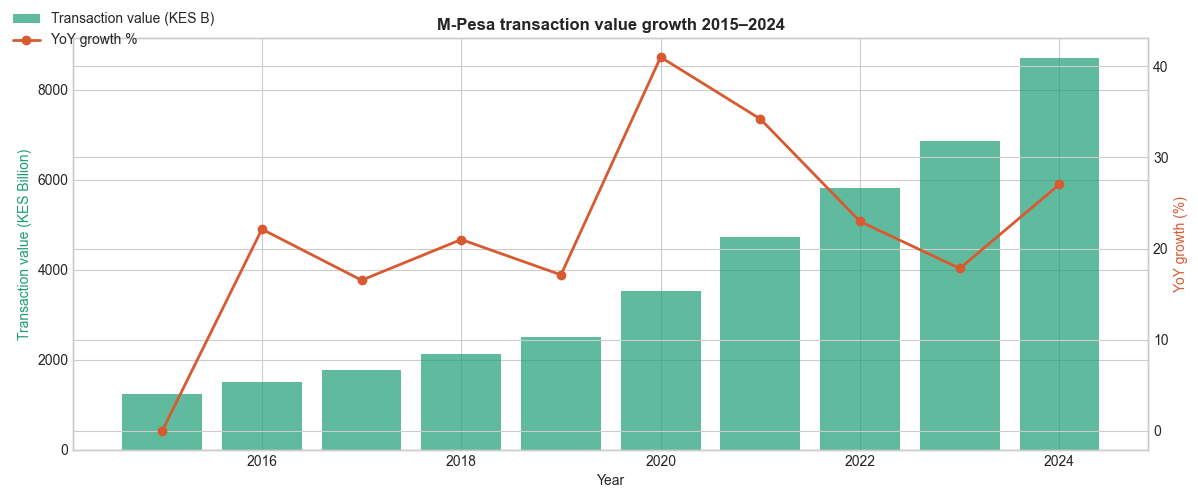

In [4]:
# CHART 1 — How has M-Pesa transaction value grown from 2015 to 2024?
# Source: annual_kpis  |  Type: Bar + Line (dual axis)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(kpis['year'], kpis['total_txn_value_kes_b'], color=COLORS['teal'], alpha=0.7, label='Transaction value (KES B)')
ax2 = ax1.twinx()
ax2.plot(kpis['year'], kpis['yoy_value_growth_pct'] * 100, color=COLORS['coral'], marker='o', linewidth=2, label='YoY growth %')
ax1.set_xlabel('Year')
ax1.set_ylabel('Transaction value (KES Billion)', color= COLORS['teal'])
ax2.set_ylabel('YoY growth (%)', color= COLORS['coral'])
ax1.set_title('M-Pesa transaction value growth 2015–2024', fontweight='bold')
fig.legend(loc="upper left")
fig.tight_layout()

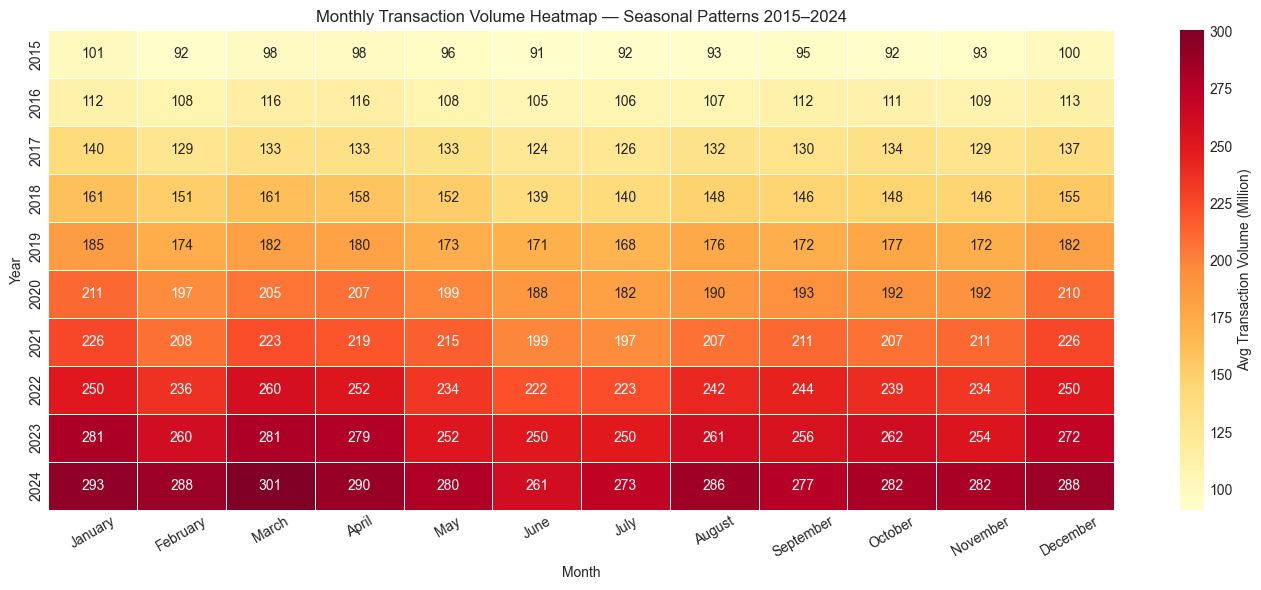

In [6]:
# CHART 2 — Which months consistently peak in transaction volume?
# Source: monthly  |  Type: Heatmap (Year × Month)

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
 
pivot = monthly.pivot_table(
    index="year", columns="month_name",
    values="txn_volume_m", aggfunc="mean"
)[month_order]
 
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Avg Transaction Volume (Million)"},
            ax=ax)
ax.set_title("Monthly Transaction Volume Heatmap — Seasonal Patterns 2015–2024")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()

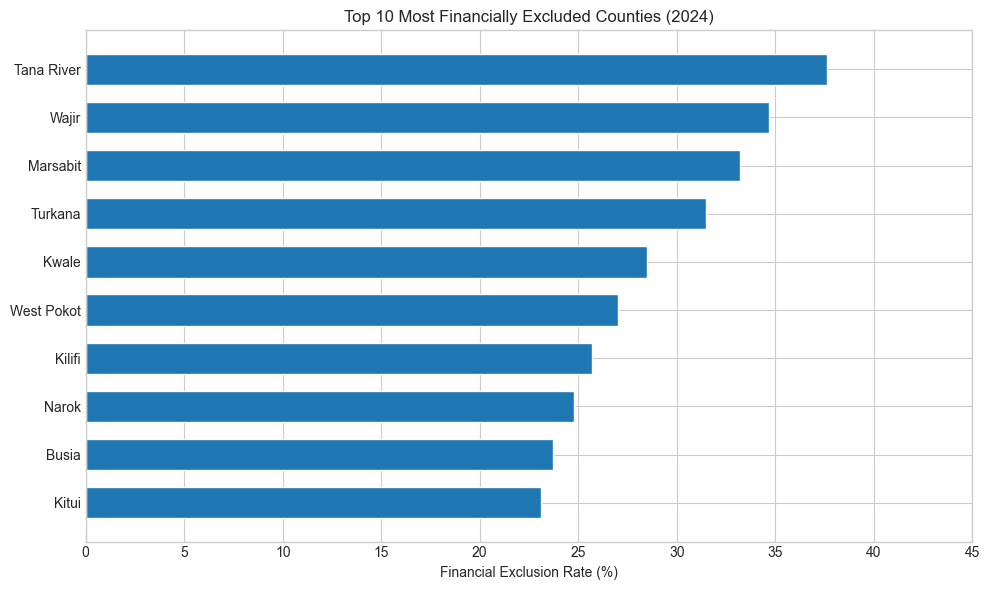

In [7]:
# CHART 3 — Which 10 counties have the highest financial exclusion?
# Source: county  |  Type: Horizontal bar chart

top10= county.nlargest(10, 'exclusion_pct').sort_values('exclusion_pct')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10["county_name"], top10["exclusion_pct"] * 100,
               edgecolor="white", height=0.65)
ax.set_xlabel("Financial Exclusion Rate (%)")
ax.set_title("Top 10 Most Financially Excluded Counties (2024)")
ax.set_xlim(0, 45)
fig.tight_layout()

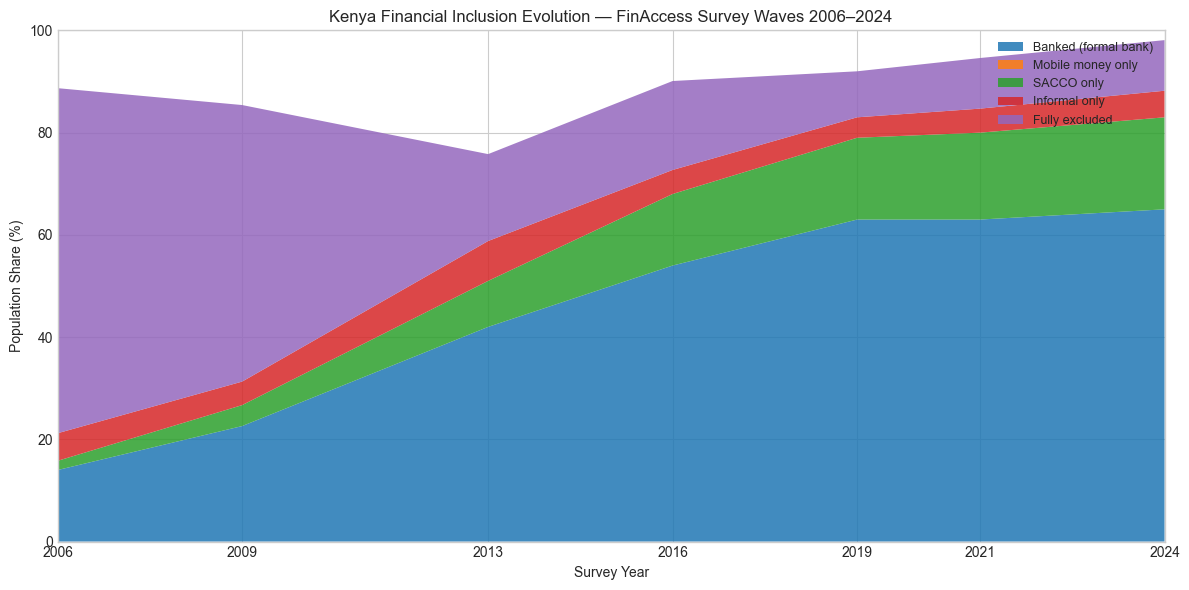

In [8]:
fa = finaccess.sort_values("survey_year")
 
fig, ax = plt.subplots(figsize=(12, 6))
 
ax.stackplot(
    fa["survey_year"],
    fa["banked_pct"] * 100,
    (fa["mobile_money_pct"] - fa["banked_pct"]).clip(lower=0) * 100,
    fa["sacco_pct"] * 100,
    fa["informal_only_pct"] * 100,
    fa["excluded_pct"] * 100,
    labels=["Banked (formal bank)", "Mobile money only",
            "SACCO only", "Informal only", "Fully excluded"],
    alpha=0.85,
)
 
ax.set_xlabel("Survey Year")
ax.set_ylabel("Population Share (%)")
ax.set_title("Kenya Financial Inclusion Evolution — FinAccess Survey Waves 2006–2024")
ax.set_xticks(fa["survey_year"])
ax.set_xlim(2006, 2024)
ax.set_ylim(0, 100)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
fig.tight_layout()

TypeError: unsupported operand type(s) for *: 'SeriesGroupBy' and 'int'

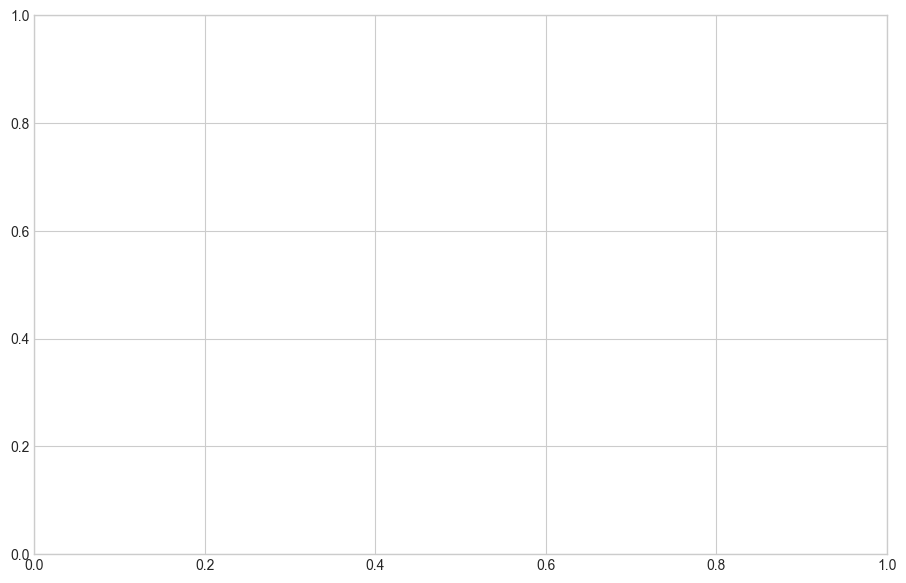

In [9]:
merged= county.merge(agents[['county_name', 'agents_per_10k_pop', 'agent_density_tier']], on= 'county_name', how='inner')

fig, ax= plt.subplots(figsize= (11, 7))
grouped= merged.groupby('region')

ax.scatter(grouped['agents_per_10k_pop'],
           grouped['formal_inclusion_pct'] * 100,
           label= region,
           s= grouped['population_2024']/18000,
           alpha= 0.75,
           edgecolors= 'white',
           linewidth= 0.8)
ax.set_xlabel("Active Agents per 1,000 Population")
ax.set_ylabel("Formal Financial Inclusion (%)")
ax.set_title(
    f"Agent Density vs Financial Inclusion by County (r = {r:.2f}, p = {p:.3f})\n"
    f"Bubble size = county population"
)
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
fig.tight_layout()

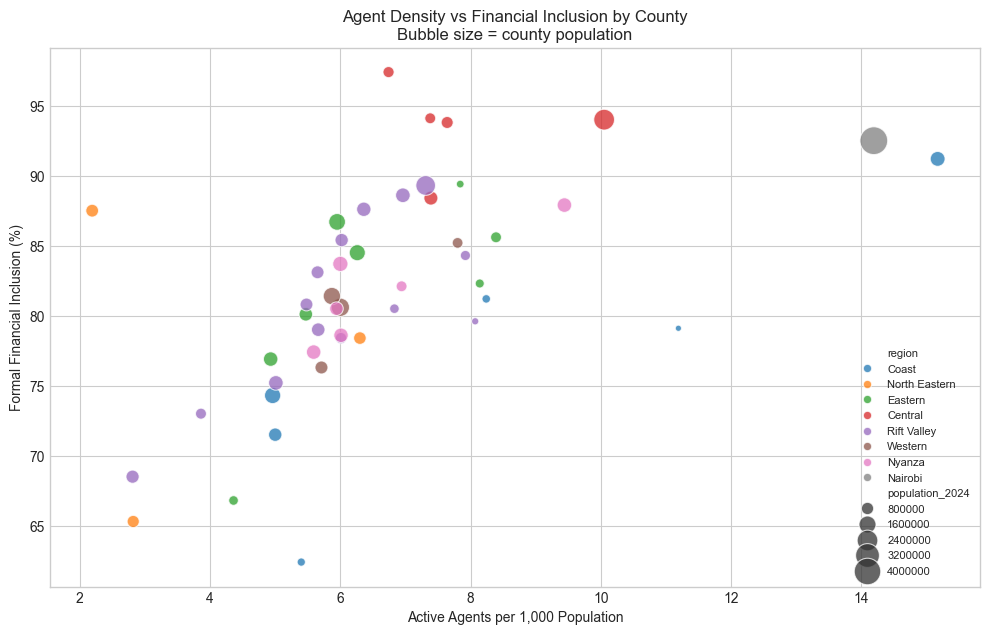

In [10]:

# CHART 5 — Is there a relationship between agent density and inclusion?
# Source: county + agents (merged)  |  Type: Scatter with regression line

merged= county.merge(agents[['county_name', 'agents_per_10k_pop', 'agent_density_tier']], on= 'county_name', how='inner')
plt.figure(figsize= (12, 7))
sns.scatterplot(
    data=merged,
    x="agents_per_10k_pop",
    y=merged["formal_inclusion_pct"] * 100,
    hue="region",                # automatically groups by region
    size="population_2024",      # bubble size
    sizes=(20, 400),             # scale bubble sizes     
    alpha=0.75,
    edgecolor="white",
    linewidth=0.8
)
plt.xlabel("Active Agents per 1,000 Population")
plt.ylabel("Formal Financial Inclusion (%)")
plt.title(
    f"Agent Density vs Financial Inclusion by County\n"
    f"Bubble size = county population"
)
plt.legend(loc="lower right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()

Chart — Mobile money as % of GDP over time


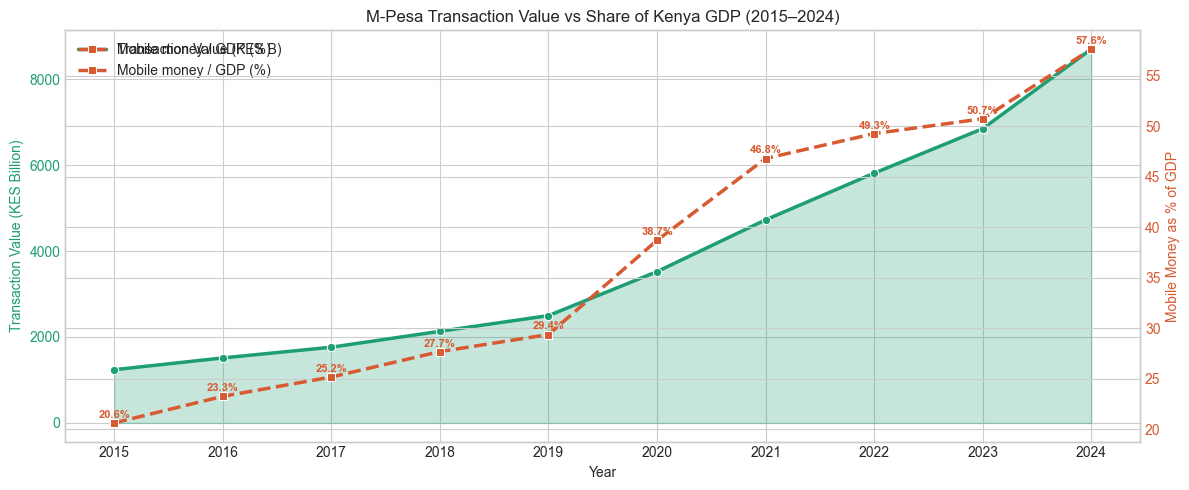

In [11]:

# CHART — How big is mobile money relative to Kenya's GDP?
# Source: kpis  |  Type: Dual-axis line chart

print("Chart — Mobile money as % of GDP over time")

fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis: transaction value
sns.lineplot(
    data=kpis,
    x="year", y="total_txn_value_kes_b",
    ax=ax1,color= COLORS["teal"], marker="o", linewidth=2.5,
    label="Transaction Value (KES B)"
)
ax1.fill_between(
    kpis["year"], kpis["total_txn_value_kes_b"],
    alpha=0.25, color= COLORS["teal"]
)
ax1.set_ylabel("Transaction Value (KES Billion)", color=COLORS["teal"])
ax1.tick_params(axis="y", labelcolor=COLORS["teal"])
ax1.set_xlabel("Year")

# Right axis: mobile money as % of GDP
ax2 = ax1.twinx()
sns.lineplot(
    data=kpis,
    x="year", y=kpis["mobile_money_gdp_pct"] * 100,
    ax=ax2, color=COLORS["coral"], marker="s", linewidth=2.5,
    linestyle="--", label="Mobile money / GDP (%)"
)
ax2.set_ylabel("Mobile Money as % of GDP", color=COLORS["coral"])
ax2.tick_params(axis="y", labelcolor=COLORS["coral"])

# Annotations (vectorized, no loop)
ax2.scatter(
    kpis["year"], kpis["mobile_money_gdp_pct"] * 100,
    alpha=0  # invisible points, just to anchor text
)
for x, y, val in zip(kpis["year"], kpis["mobile_money_gdp_pct"] * 100, kpis["mobile_money_gdp_pct"]):
    ax2.text(x, y + 0.5, f"{val*100:.1f}%", ha="center",
             fontsize=8, color=COLORS["coral"], fontweight="bold")

ax1.set_xticks(kpis["year"])
ax1.set_title("M-Pesa Transaction Value vs Share of Kenya GDP (2015–2024)")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.9)

fig.tight_layout()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_18372\887744098.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


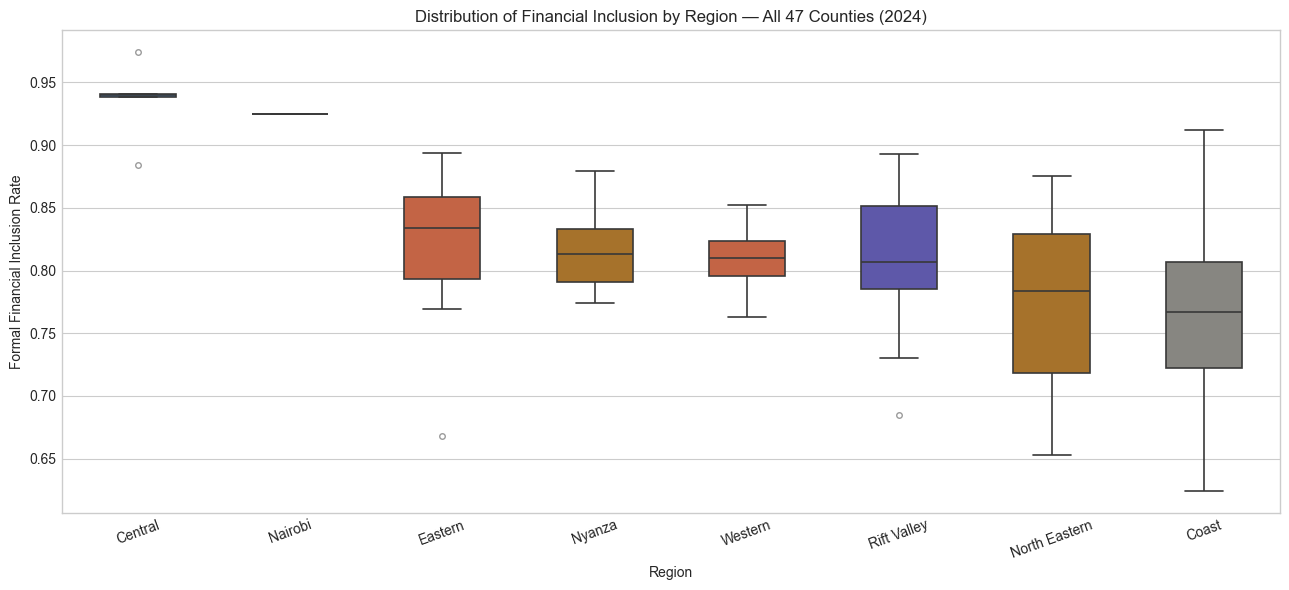

In [14]:
# CHART 10 — County inclusion rate distribution across Kenya
# Source: county  |  Type: Box plot by region + strip plot

region_order = (
    county.groupby("region")["formal_inclusion_pct"]
    .median().sort_values(ascending=False).index.tolist()
)
 
fig, ax = plt.subplots(figsize=(13, 6))
 
sns.boxplot(
    data=county,
    x="region", y="formal_inclusion_pct",
    order=region_order,
    palette=[COLORS["blue"], COLORS["teal"], COLORS["coral"], COLORS["amber"],
             COLORS["coral"], COLORS["purple"], COLORS["amber"], COLORS["gray"]],
    width=0.5, linewidth=1.2,
    flierprops=dict(marker="o", markersize=4, alpha=0.5),
    ax=ax,
)
ax.set_xlabel("Region")
ax.set_ylabel("Formal Financial Inclusion Rate")
ax.set_title("Distribution of Financial Inclusion by Region — All 47 Counties (2024)")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()

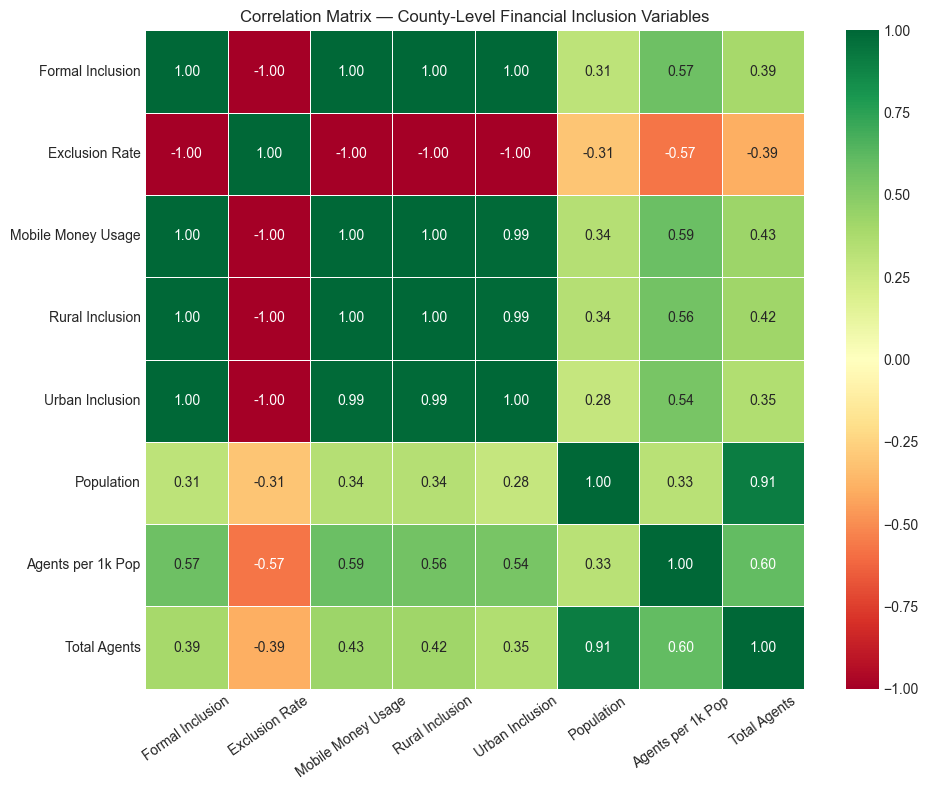

In [15]:
# CHART 11 — Correlation heatmap (county-level variables)
# Source: county + agents merged  |  Type: Heatmap
 
merged_corr = county.merge(
    agents[["county_name", "agents_per_10k_pop", "active_agents_2024"]],
    on="county_name", how="inner"
)
 
corr_cols = {
    "formal_inclusion_pct"  : "Formal Inclusion",
    "exclusion_pct"         : "Exclusion Rate",
    "mobile_money_usage_pct": "Mobile Money Usage",
    "rural_inclusion_pct"   : "Rural Inclusion",
    "urban_inclusion_pct"   : "Urban Inclusion",
    "population_2024"       : "Population",
    "agents_per_10k_pop"    : "Agents per 1k Pop",
    "active_agents_2024"    : "Total Agents",
}
 
corr_df = merged_corr[list(corr_cols.keys())].rename(columns=corr_cols)
corr_matrix = corr_df.corr()
 
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor="white",
    square=True, ax=ax,
    annot_kws={"size": 10},
)
ax.set_title("Correlation Matrix — County-Level Financial Inclusion Variables")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()